In [4]:
import os
import requests
from tqdm import tqdm

URL = "http://hog.ee.columbia.edu/craffel/lmd/lmd_matched.tar.gz"
OUT_FILE = "lmd_matched.tar.gz"

def download_file(url, filename):
    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))
    
    with open(filename, "wb") as f, tqdm(
        desc=filename,
        total=total,
        unit='B',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for chunk in response.iter_content(chunk_size=1024):
            if chunk:
                f.write(chunk)
                bar.update(len(chunk))

if not os.path.exists(OUT_FILE):
    download_file(URL, OUT_FILE)
else:
    print("File already downloaded.")

lmd_matched.tar.gz: 100%|██████████| 1.31G/1.31G [02:05<00:00, 11.2MB/s] 


In [5]:
import tarfile

def extract_tar(file_path, extract_to="."):
    with tarfile.open(file_path, "r:gz") as tar:
        tar.extractall(path=extract_to)

extract_tar("lmd_matched.tar.gz", "lmd_matched")

In [6]:
import requests

META_URL = "http://millionsongdataset.com/sites/default/files/AdditionalFiles/msd_summary_file.h5"
META_FILE = "msd_summary_file.h5"

if not os.path.exists(META_FILE):
    download_file(META_URL, META_FILE)
else:
    print("Metadata already downloaded.")

msd_summary_file.h5: 100%|██████████| 301M/301M [00:23<00:00, 13.7MB/s] 


In [8]:
import h5py

with h5py.File("msd_summary_file.h5", "r") as f:
    print("Top-level keys:", list(f.keys()))
    print("\nmetadata keys:", list(f["metadata"].keys()))
    print("\nmusicbrainz keys:", list(f["musicbrainz"].keys()))
    
    songs = f["metadata"]["songs"]
    print("\nAvailable fields in metadata/songs:")
    print(songs.dtype.names)

Top-level keys: ['analysis', 'metadata', 'musicbrainz']

metadata keys: ['songs']

musicbrainz keys: ['songs']

Available fields in metadata/songs:
('analyzer_version', 'artist_7digitalid', 'artist_familiarity', 'artist_hotttnesss', 'artist_id', 'artist_latitude', 'artist_location', 'artist_longitude', 'artist_mbid', 'artist_name', 'artist_playmeid', 'genre', 'idx_artist_terms', 'idx_similar_artists', 'release', 'release_7digitalid', 'song_hotttnesss', 'song_id', 'title', 'track_7digitalid')


In [ ]:
import h5py
import pandas as pd

def load_msd_metadata(h5_path):
    with h5py.File(h5_path, 'r') as f:
        meta = f["metadata"]["songs"]
        mb = f["musicbrainz"]["songs"]
        
        df = pd.DataFrame({
            "song_id": meta["song_id"],
            "artist": meta["artist_name"],
            "title": meta["title"],
            "year": mb["year"],
            #"genre": meta["genre"]
        })
    
    # decode byte strings
    for col in ["song_id", "artist", "title"]:
        df[col] = df[col].apply(lambda x: x.decode("utf-8"))
    
    return df

msd_df = load_msd_metadata("msd_summary_file.h5")
print(msd_df.head())

              song_id            artist              title  year genre
0  SOQMMHC12AB0180CB8  Faster Pussy cat       Silent Night  2003   b''
1  SOVFVAK12A8C1350D9  Karkkiautomaatti        Tanssi vaan  1995   b''
2  SOGTUKN12AB017F4F1    Hudson Mohawke  No One Could Ever  2006   b''
3  SOBNYVR12A8C13558C       Yerba Brava      Si Vos Querés  2003   b''
4  SOHSBXH12A8C13B0DF        Der Mystic   Tangle Of Aspens     0   b''


In [25]:
msd_df.genre.value_counts()

genre
b''    1000000
Name: count, dtype: int64

In [17]:
len(msd_df.drop_duplicates(subset=['song_id']))

999056

In [10]:
from pathlib import Path

midi_root = Path("lmd_matched")

midi_files = list(midi_root.rglob("*.mid"))

print(f"Total MIDI files: {len(midi_files)}")

# show a few examples
for f in midi_files[:5]:
    print(f)

Total MIDI files: 116189
lmd_matched/lmd_matched/L/L/L/TRLLLJH12903CC3D7C/1623e6e2f5814e933219033070e77d15.mid
lmd_matched/lmd_matched/L/L/L/TRLLLJH12903CC3D7C/bf6b4e2dc82df12ff81bd7be22fa23f5.mid
lmd_matched/lmd_matched/L/L/L/TRLLLJH12903CC3D7C/3d31d08f5561d428c8e8f00de9a7a9db.mid
lmd_matched/lmd_matched/L/L/L/TRLLLJH12903CC3D7C/2fbe5a3170e4fa377136f053c8222e76.mid
lmd_matched/lmd_matched/L/L/L/TRLLLJH12903CC3D7C/36a5dc3f3528a85d4dc54b1af0116218.mid


In [ ]:
import pretty_midi
import random

sample_path = random.choice(midi_files)

pm = pretty_midi.PrettyMIDI(str(sample_path))

print("File:", sample_path)
print("Instruments:", len(pm.instruments))
print("Tempo changes:", pm.get_tempo_changes()[1][:5])
print("Duration (sec):", pm.get_end_time())

File: lmd_matched/lmd_matched/B/V/R/TRBVRSF128F92D5D2F/5324e940f83f6e2f8743b52efec8d62d.mid
Instruments: 12
Tempo changes: [135.000135   136.00014507 137.00006393 136.00014507 135.000135  ]
Duration (sec): 190.900373


Year range: 1922 - 2011
Songs with year: 515576


<Axes: >

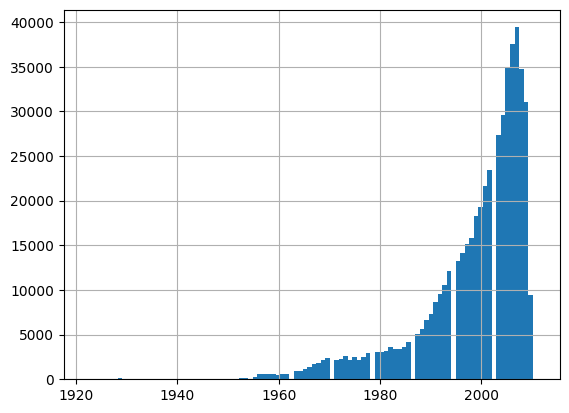

In [22]:
# keep only songs with valid year
valid_years = msd_df[msd_df["year"] > 0]

print("Year range:", valid_years["year"].min(), "-", valid_years["year"].max())
print("Songs with year:", len(valid_years))

# simple histogram
valid_years["year"].hist(bins=100)

In [20]:
valid_years.year.value_counts()[:20]

year
2007    39414
2006    37546
2005    34960
2008    34770
2009    31051
2004    29618
2003    27389
2002    23472
2001    21604
2000    19293
1999    18262
1998    15858
1997    15182
1996    14135
1995    13260
1994    12127
1993    10529
1992     9547
2010     9397
1991     8650
Name: count, dtype: int64